In [22]:
# ============================================
# DATATHON 2026 - SALES FORECASTING PIPELINE
# Enhanced version with holiday features, interaction terms,
# expanding window CV, and post-processing
# ============================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Models
import xgboost as xgb
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor
from sklearn.linear_model import Ridge, Lasso, ElasticNet
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler

# Time series
from prophet import Prophet
import holidays

# Progress bar
from tqdm import tqdm

import os
from datetime import datetime

In [23]:
# Set random seed for reproducibility
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

print("=" * 60)
print("DATATHON 2026 - ENHANCED SALES FORECASTING PIPELINE")
print("=" * 60)

DATATHON 2026 - ENHANCED SALES FORECASTING PIPELINE


In [24]:
# ============================================
# 1. DATA LOADING
# ============================================

DATA_DIR = '../data'

print("\n[1] Loading data...")

# Load training data
train_data = pd.read_csv(os.path.join(DATA_DIR, 'processed', 'sales_cleaned.csv'), parse_dates=['Date'])
print(f"  Training data: {len(train_data)} rows, from {train_data['Date'].min()} to {train_data['Date'].max()}")

# Load sample submission for test dates
sample_sub = pd.read_csv(os.path.join(DATA_DIR, 'raw','sample_submission.csv'), parse_dates=['Date'])
test_dates = sample_sub['Date'].values
print(f"  Test period: from {test_dates.min()} to {test_dates.max()} ({len(test_dates)} days)")

# Create a copy
df = train_data.copy()
df = df.sort_values('Date').reset_index(drop=True)



[1] Loading data...
  Training data: 3833 rows, from 2012-07-04 00:00:00 to 2022-12-31 00:00:00
  Test period: from 2023-01-01T00:00:00.000000 to 2024-07-01T00:00:00.000000 (548 days)


In [25]:
# ============================================
# 2. FEATURE ENGINEERING (FIXED VERSION)
# ============================================

print("\n[2] Feature engineering...")

# 2.1 Basic time features
df['year'] = df['Date'].dt.year
df['month'] = df['Date'].dt.month
df['day'] = df['Date'].dt.day
df['dayofweek'] = df['Date'].dt.dayofweek
df['weekofyear'] = df['Date'].dt.isocalendar().week.astype(int)
df['quarter'] = df['Date'].dt.quarter
df['dayofyear'] = df['Date'].dt.dayofyear

# 2.2 Cyclic encoding for periodic features
df['month_sin'] = np.sin(2 * np.pi * df['month'] / 12)
df['month_cos'] = np.cos(2 * np.pi * df['month'] / 12)
df['dayofweek_sin'] = np.sin(2 * np.pi * df['dayofweek'] / 7)
df['dayofweek_cos'] = np.cos(2 * np.pi * df['dayofweek'] / 7)
df['dayofyear_sin'] = np.sin(2 * np.pi * df['dayofyear'] / 365.25)
df['dayofyear_cos'] = np.cos(2 * np.pi * df['dayofyear'] / 365.25)

# 2.3 Weekend flag
df['is_weekend'] = df['dayofweek'].isin([5, 6]).astype(int)

# 2.4 Basic holiday flags (from original code)
basic_holidays = ['01-01', '02-14', '03-08', '04-30', '05-01', '09-02', '10-20', '11-11', '12-12', '12-24']
df['is_basic_holiday'] = df['Date'].dt.strftime('%m-%d').isin(basic_holidays).astype(int)

# 2.5 VIETNAMESE HOLIDAYS (Fixed - no external package issues)
print("  Adding Vietnamese holiday features...")

# Define Vietnam holidays manually (fixed dates)
vn_holiday_set = set()
tet_dates_by_year = {}

# Fixed-date holidays
for year in range(2012, 2025):
    vn_holiday_set.add(pd.Timestamp(f'{year}-01-01'))  # New Year
    vn_holiday_set.add(pd.Timestamp(f'{year}-04-30'))  # Reunification Day  
    vn_holiday_set.add(pd.Timestamp(f'{year}-05-01'))  # Labor Day
    vn_holiday_set.add(pd.Timestamp(f'{year}-09-02'))  # National Day

# Tet holidays (Lunar New Year - approximate dates)
tet_dates = {
    2012: '2012-01-23', 2013: '2013-02-10', 2014: '2014-01-31',
    2015: '2015-02-19', 2016: '2016-02-08', 2017: '2017-01-28',
    2018: '2018-02-16', 2019: '2019-02-05', 2020: '2020-01-25',
    2021: '2021-02-12', 2022: '2022-02-01', 2023: '2023-01-22',
    2024: '2024-02-10', 2025: '2025-01-29'
}

for year, tet_date in tet_dates.items():
    tet_ts = pd.Timestamp(tet_date)
    vn_holiday_set.add(tet_ts)
    tet_dates_by_year[year] = tet_ts

def get_holiday_info(date):
    """Extract comprehensive holiday information"""
    date_ts = pd.to_datetime(date)
    date_obj = date_ts.date()
    year = date_ts.year
    
    # Check if date is a holiday (using date object for comparison)
    is_holiday = date_ts in vn_holiday_set
    
    # Determine holiday type
    holiday_type = 'none'
    if is_holiday:
        month_day = date_ts.strftime('%m-%d')
        if month_day == '01-01':
            holiday_type = 'new_year'
        elif month_day == '04-30':
            holiday_type = 'reunification'
        elif month_day == '05-01':
            holiday_type = 'labor'
        elif month_day == '09-02':
            holiday_type = 'national_day'
        else:
            holiday_type = 'tet'  # Assume any other holiday is Tet-related
    
    # Get Tet date for the year
    tet_date = tet_dates_by_year.get(year)
    
    if tet_date:
        days_to_tet = (tet_date - date_ts).days
        days_since_tet = (date_ts - tet_date).days
        is_tet_period = (-7 <= days_to_tet <= 7) or (0 <= days_since_tet <= 7)
    else:
        days_to_tet = 365
        days_since_tet = 365
        is_tet_period = False
    
    # Days to next holiday
    future_holidays = [h for h in vn_holiday_set if h >= date_ts]
    days_to_next_holiday = (min(future_holidays) - date_ts).days if future_holidays else 365
    
    # Days since last holiday
    past_holidays = [h for h in vn_holiday_set if h <= date_ts]
    days_since_last_holiday = (date_ts - max(past_holidays)).days if past_holidays else 365
    
    return pd.Series({
        'is_vn_holiday': int(is_holiday),
        'holiday_type': holiday_type,
        'days_to_next_holiday': days_to_next_holiday,
        'days_since_last_holiday': days_since_last_holiday,
        'days_to_tet': days_to_tet,
        'days_since_tet': days_since_tet,
        'is_tet_period': int(is_tet_period),
    })

# Apply holiday features safely
holiday_features = df['Date'].apply(get_holiday_info)
for col in holiday_features.columns:
    df[col] = holiday_features[col].values

# 2.6 SALE PERIOD FEATURES (Black Friday, 11.11, 12.12)
print("  Adding sale period features...")

def get_sale_features(date):
    date_ts = pd.to_datetime(date)
    year = date_ts.year
    
    # Black Friday (last Friday of November)
    try:
        nov_dates = pd.date_range(f'{year}-11-01', f'{year}-11-30')
        black_fridays = nov_dates[nov_dates.dayofweek == 4]  # Friday = 4
        black_friday = black_fridays[-1] if len(black_fridays) > 0 else None
    except:
        black_friday = None
    
    # 11.11 Single's Day and 12.12
    is_1111 = (date_ts.month == 11 and date_ts.day == 11)
    is_1212 = (date_ts.month == 12 and date_ts.day == 12)
    
    if black_friday:
        days_to_bf = (black_friday - date_ts).days
        days_since_bf = (date_ts - black_friday).days
    else:
        days_to_bf = 365
        days_since_bf = 365
    
    # Sale intensity (1=normal, 2=mid, 3=peak)
    if days_to_bf == 0 or days_since_bf == 0 or is_1111 or is_1212:
        sale_intensity = 3
    elif (1 <= abs(days_to_bf) <= 3) or (1 <= abs(days_since_bf) <= 3):
        sale_intensity = 2
    else:
        sale_intensity = 1
    
    return pd.Series({
        'is_1111': int(is_1111),
        'is_1212': int(is_1212),
        'days_to_black_friday': days_to_bf,
        'days_since_black_friday': days_since_bf,
        'sale_intensity': sale_intensity,
    })

# Apply sale features
sale_features = df['Date'].apply(get_sale_features)
for col in sale_features.columns:
    df[col] = sale_features[col].values

# 2.7 LAG FEATURES
print("  Creating lag features...")

lags = [1, 2, 3, 7, 14, 30, 60, 90, 365]

for lag in lags:
    df[f'Revenue_lag_{lag}'] = df['Revenue'].shift(lag)
    df[f'COGS_lag_{lag}'] = df['COGS'].shift(lag)

# 2.8 ROLLING WINDOW FEATURES (with shift to avoid leakage)
windows = [7, 14, 30, 60, 90]

for w in windows:
    # Rolling means and stds (using shift(1) to avoid using current day)
    df[f'Revenue_roll_mean_{w}'] = df['Revenue'].shift(1).rolling(w, min_periods=1).mean()
    df[f'Revenue_roll_std_{w}'] = df['Revenue'].shift(1).rolling(w, min_periods=1).std()
    df[f'COGS_roll_mean_{w}'] = df['COGS'].shift(1).rolling(w, min_periods=1).mean()
    df[f'COGS_roll_std_{w}'] = df['COGS'].shift(1).rolling(w, min_periods=1).std()
    
    # Rolling min/max
    df[f'Revenue_roll_min_{w}'] = df['Revenue'].shift(1).rolling(w, min_periods=1).min()
    df[f'Revenue_roll_max_{w}'] = df['Revenue'].shift(1).rolling(w, min_periods=1).max()
    df[f'COGS_roll_min_{w}'] = df['COGS'].shift(1).rolling(w, min_periods=1).min()
    df[f'COGS_roll_max_{w}'] = df['COGS'].shift(1).rolling(w, min_periods=1).max()

# 2.9 RATE OF CHANGE FEATURES
print("  Creating rate of change features...")

for period in [7, 14, 30, 90]:
    # Safe division by adding small epsilon
    denominator = df[f'Revenue_lag_{period}'].abs() + 1
    df[f'Revenue_pct_change_{period}d'] = (df['Revenue'] - df[f'Revenue_lag_{period}']) / denominator
    
    denominator_cogs = df[f'COGS_lag_{period}'].abs() + 1
    df[f'COGS_pct_change_{period}d'] = (df['COGS'] - df[f'COGS_lag_{period}']) / denominator_cogs

# 2.10 INTERACTION FEATURES
print("  Creating interaction features...")

df['month_weekend_interaction'] = df['month'] * df['is_weekend']
df['month_tet_interaction'] = df['month'] * df['is_tet_period']
df['weekend_sale_interaction'] = df['is_weekend'] * df['sale_intensity']
df['holiday_weekend_interaction'] = df['is_basic_holiday'] * df['is_weekend']

# 2.11 CUMULATIVE FEATURES
df['cumulative_revenue_ytd'] = df.groupby('year')['Revenue'].cumsum()
df['cumulative_cogs_ytd'] = df.groupby('year')['COGS'].cumsum()

# 2.12 EXPANDING MEANS BY CATEGORY (with shift)
print("  Creating expanding means...")

for group_col in ['month', 'dayofweek', 'quarter']:
    # Expanding mean with shift to avoid leakage
    exp_mean_rev = df.groupby(group_col)['Revenue'].expanding().mean()
    df[f'expanding_mean_rev_by_{group_col}'] = exp_mean_rev.reset_index(level=0, drop=True).shift(1)
    
    exp_mean_cogs = df.groupby(group_col)['COGS'].expanding().mean()
    df[f'expanding_mean_cogs_by_{group_col}'] = exp_mean_cogs.reset_index(level=0, drop=True).shift(1)

# 2.13 GROSS MARGIN
df['gross_margin'] = (df['Revenue'] - df['COGS']) / (df['Revenue'] + 1)
df['gross_margin_lag_1'] = df['gross_margin'].shift(1)
df['gross_margin_roll_mean_7'] = df['gross_margin'].shift(1).rolling(7, min_periods=1).mean()

# 2.14 MARKET TREND FEATURES
df['revenue_ratio_to_7d_avg'] = df['Revenue'] / (df['Revenue_roll_mean_7'].abs() + 1)
df['revenue_ratio_to_30d_avg'] = df['Revenue'] / (df['Revenue_roll_mean_30'].abs() + 1)

# 2.15 Fill NaN values with 0 or forward fill
print("  Handling missing values...")

# For specific columns, use forward fill then 0
ffill_cols = [f'Revenue_lag_{lag}' for lag in lags] + \
             [f'COGS_lag_{lag}' for lag in lags] + \
             [f'Revenue_roll_mean_{w}' for w in windows] + \
             [f'COGS_roll_mean_{w}' for w in windows] + \
             ['gross_margin_lag_1', 'gross_margin_roll_mean_7']

for col in ffill_cols:
    if col in df.columns:
        df[col] = df[col].ffill().fillna(0)

# For std and other columns, fill NaN with 0
all_other_cols = [f'Revenue_roll_std_{w}' for w in windows] + \
                 [f'COGS_roll_std_{w}' for w in windows] + \
                 [f'Revenue_roll_min_{w}' for w in windows] + \
                 [f'COGS_roll_min_{w}' for w in windows] + \
                 [f'Revenue_roll_max_{w}' for w in windows] + \
                 [f'COGS_roll_max_{w}' for w in windows] + \
                 [f'expanding_mean_rev_by_{g}' for g in ['month', 'dayofweek', 'quarter']] + \
                 [f'expanding_mean_cogs_by_{g}' for g in ['month', 'dayofweek', 'quarter']] + \
                 ['cumulative_revenue_ytd', 'cumulative_cogs_ytd']

for col in all_other_cols:
    if col in df.columns:
        df[col] = df[col].fillna(0)

# 2.16 Drop any remaining NaN rows (should be minimal now)
df = df.dropna().reset_index(drop=True)

print(f"  Data shape after feature engineering: {df.shape}")
print(f"  Columns: {len(df.columns)}")
print(f"  Date range: {df['Date'].min()} to {df['Date'].max()}")


[2] Feature engineering...
  Adding Vietnamese holiday features...
  Adding sale period features...
  Creating lag features...
  Creating rate of change features...
  Creating interaction features...
  Creating expanding means...
  Handling missing values...
  Data shape after feature engineering: (3743, 113)
  Columns: 113
  Date range: 2012-10-02 00:00:00 to 2022-12-31 00:00:00


In [26]:
# ============================================
# 3. FEATURE SELECTION
# ============================================

print("\n[3] Selecting features...")

# Core features
core_features = [
    'year', 'month', 'day', 'quarter',
    'dayofweek', 'weekofyear', 'dayofyear',
    'month_sin', 'month_cos', 'dayofweek_sin', 'dayofweek_cos',
    'dayofyear_sin', 'dayofyear_cos',
    'is_weekend', 'is_basic_holiday', 'is_vn_holiday',
    'days_to_next_holiday', 'days_since_last_holiday',
    'days_to_tet', 'days_since_tet', 'is_tet_period',
    'is_1111', 'is_1212', 'days_to_black_friday', 'days_since_black_friday',
    'sale_intensity',
    'month_weekend_interaction', 'month_tet_interaction',
    'weekend_sale_interaction', 'holiday_weekend_interaction',
]

# Lag features
lag_features_rev = [f'Revenue_lag_{lag}' for lag in lags]
lag_features_cogs = [f'COGS_lag_{lag}' for lag in lags]

# Rolling features
roll_features_rev = []
roll_features_cogs = []
for w in windows:
    roll_features_rev.extend([f'Revenue_roll_mean_{w}', f'Revenue_roll_std_{w}', 
                              f'Revenue_roll_min_{w}', f'Revenue_roll_max_{w}'])
    roll_features_cogs.extend([f'COGS_roll_mean_{w}', f'COGS_roll_std_{w}',
                               f'COGS_roll_min_{w}', f'COGS_roll_max_{w}'])

# Rate of change features
pct_change_features_rev = [f'Revenue_pct_change_{period}d' for period in [7, 14, 30, 90]]
pct_change_features_cogs = [f'COGS_pct_change_{period}d' for period in [7, 14, 30, 90]]

# Expanding mean features
expanding_rev_features = [f'expanding_mean_rev_by_{col}' for col in ['month', 'dayofweek', 'quarter']]
expanding_cogs_features = [f'expanding_mean_cogs_by_{col}' for col in ['month', 'dayofweek', 'quarter']]

# Additional features
additional_features = [
    'cumulative_revenue_ytd', 'cumulative_cogs_ytd',
    'gross_margin_lag_1', 'gross_margin_roll_mean_7',
    'revenue_ratio_to_7d_avg', 'revenue_ratio_to_30d_avg',
]

# Combine features for Revenue and COGS
features_for_revenue = (core_features + lag_features_rev + lag_features_cogs + 
                        roll_features_rev + roll_features_cogs + 
                        pct_change_features_rev + pct_change_features_cogs +
                        expanding_rev_features + expanding_cogs_features +
                        additional_features)

features_for_cogs = (core_features + lag_features_cogs + roll_features_cogs +
                     pct_change_features_cogs + expanding_cogs_features +
                     ['cumulative_cogs_ytd'])

# Remove duplicates while preserving order
features_for_revenue = list(dict.fromkeys(features_for_revenue))
features_for_cogs = list(dict.fromkeys(features_for_cogs))

print(f"  Features for Revenue: {len(features_for_revenue)}")
print(f"  Features for COGS: {len(features_for_cogs)}")



[3] Selecting features...
  Features for Revenue: 108
  Features for COGS: 67


In [27]:
# ============================================
# 4. TRAIN/VALIDATION SPLIT (Expanding Window)
# ============================================

print("\n[4] Setting up training/validation...")

# Use 2022 as validation
train_mask = df['Date'] < '2022-01-01'
val_mask = (df['Date'] >= '2022-01-01') & (df['Date'] <= '2022-12-31')

X_train_rev = df.loc[train_mask, features_for_revenue]
y_train_rev = df.loc[train_mask, 'Revenue']
X_val_rev = df.loc[val_mask, features_for_revenue]
y_val_rev = df.loc[val_mask, 'Revenue']

X_train_cogs = df.loc[train_mask, features_for_cogs]
y_train_cogs = df.loc[train_mask, 'COGS']
X_val_cogs = df.loc[val_mask, features_for_cogs]
y_val_cogs = df.loc[val_mask, 'COGS']

print(f"  Train: {len(X_train_rev)} days")
print(f"  Validation: {len(X_val_rev)} days")



[4] Setting up training/validation...
  Train: 3378 days
  Validation: 365 days


In [29]:
# ============================================
# 5. PROPHET MODELS (FIXED VERSION)
# ============================================

print("\n[5] Training Prophet models...")

# Prepare data for Prophet
prophet_train_rev = df.loc[train_mask, ['Date', 'Revenue']].rename(columns={'Date': 'ds', 'Revenue': 'y'})
prophet_train_cogs = df.loc[train_mask, ['Date', 'COGS']].rename(columns={'Date': 'ds', 'COGS': 'y'})

# Add holiday data to Prophet
# Create holidays dataframe for Prophet (FIXED - works with all versions)
prophet_holidays = []

# Try different ways to get Vietnam holidays
vn_holidays_dict = None
try:
    # Newer version (holidays >= 0.25)
    import holidays
    vn_holidays_dict = holidays.country_holidays('VN', years=range(2012, 2025))
    print("  Using holidays.country_holidays('VN')")
except:
    try:
        # Older version
        vn_holidays_dict = holidays.VietNam(years=range(2012, 2025))
        print("  Using holidays.VietNam")
    except:
        try:
            # Another older version format
            vn_holidays_dict = holidays.VN(years=range(2012, 2025))
            print("  Using holidays.VN")
        except:
            # Fallback: create custom holidays manually
            print("  Using manual holiday list (fallback)")
            from datetime import date
            vn_holidays_dict = {}
            for y in range(2012, 2025):
                vn_holidays_dict[date(y, 1, 1)] = "New Year's Day"
                vn_holidays_dict[date(y, 4, 30)] = "Reunification Day"
                vn_holidays_dict[date(y, 5, 1)] = "Labor Day"
                vn_holidays_dict[date(y, 9, 2)] = "National Day"
            
            # Tet holidays (Lunar New Year)
            tet_dates = {
                2012: (2012, 1, 23), 2013: (2013, 2, 10), 2014: (2014, 1, 31),
                2015: (2015, 2, 19), 2016: (2016, 2, 8), 2017: (2017, 1, 28),
                2018: (2018, 2, 16), 2019: (2019, 2, 5), 2020: (2020, 1, 25),
                2021: (2021, 2, 12), 2022: (2022, 2, 1), 2023: (2023, 1, 22),
                2024: (2024, 2, 10), 2025: (2025, 1, 29)
            }
            for y, (year, m, d) in tet_dates.items():
                if year >= 2012 and year <= 2024:
                    vn_holidays_dict[date(year, m, d)] = "Tet Holiday"

# Build Prophet holidays list
if vn_holidays_dict:
    for date_obj, name in vn_holidays_dict.items():
        # Convert to datetime if needed
        if not isinstance(date_obj, (pd.Timestamp, datetime)):
            date_obj = pd.Timestamp(date_obj)
        
        if hasattr(date_obj, 'year') and date_obj.year >= 2012 and date_obj.year <= 2024:
            prophet_holidays.append({
                'holiday': str(name).replace(' ', '_').lower(),
                'ds': date_obj,
                'lower_window': -3,
                'upper_window': 3,
            })
    print(f"  Loaded {len(prophet_holidays)} holidays for Prophet")
else:
    print("  No holidays loaded - using default seasonality only")

# Create holidays DataFrame (may be empty)
prophet_holidays_df = pd.DataFrame(prophet_holidays) if prophet_holidays else None

# Train Prophet for Revenue
print("  Training Prophet for Revenue...")
model_prophet_rev = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=True,
    daily_seasonality=False,
    holidays=prophet_holidays_df,
    seasonality_prior_scale=10.0,
    holidays_prior_scale=10.0,
    changepoint_prior_scale=0.05,
)
model_prophet_rev.add_seasonality(name='monthly', period=30.5, fourier_order=5)
model_prophet_rev.fit(prophet_train_rev)

# Train Prophet for COGS
print("  Training Prophet for COGS...")
model_prophet_cogs = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=True,
    daily_seasonality=False,
    holidays=prophet_holidays_df,
    seasonality_prior_scale=10.0,
    holidays_prior_scale=10.0,
    changepoint_prior_scale=0.05,
)
model_prophet_cogs.add_seasonality(name='monthly', period=30.5, fourier_order=5)
model_prophet_cogs.fit(prophet_train_cogs)

print("  Prophet models trained successfully!")

# Get Prophet predictions for train and validation
print("  Generating Prophet predictions...")
prophet_train_pred_rev = model_prophet_rev.predict(pd.DataFrame({'ds': df.loc[train_mask, 'Date']}))['yhat'].values
prophet_val_pred_rev = model_prophet_rev.predict(pd.DataFrame({'ds': df.loc[val_mask, 'Date']}))['yhat'].values

prophet_train_pred_cogs = model_prophet_cogs.predict(pd.DataFrame({'ds': df.loc[train_mask, 'Date']}))['yhat'].values
prophet_val_pred_cogs = model_prophet_cogs.predict(pd.DataFrame({'ds': df.loc[val_mask, 'Date']}))['yhat'].values

print("  Prophet predictions generated")


[5] Training Prophet models...
  Using holidays.country_holidays('VN')
  Loaded 183 holidays for Prophet
  Training Prophet for Revenue...


18:58:40 - cmdstanpy - INFO - Chain [1] start processing
18:58:44 - cmdstanpy - INFO - Chain [1] done processing


  Training Prophet for COGS...


18:58:45 - cmdstanpy - INFO - Chain [1] start processing
18:58:46 - cmdstanpy - INFO - Chain [1] done processing


  Prophet models trained successfully!
  Generating Prophet predictions...
  Prophet predictions generated


In [30]:
# ============================================
# 6. TRAIN BASE MODELS ON RESIDUALS
# ============================================

print("\n[6] Training base models on residuals...")

# Calculate residuals
residuals_train_rev = y_train_rev.values - prophet_train_pred_rev
residuals_train_cogs = y_train_cogs.values - prophet_train_pred_cogs

residuals_val_rev = y_val_rev.values - prophet_val_pred_rev
residuals_val_cogs = y_val_cogs.values - prophet_val_pred_cogs

# Model parameters
LGB_PARAMS = {
    'n_estimators': 2000,
    'learning_rate': 0.02,
    'num_leaves': 64,
    'subsample': 0.8,
    'colsample_bytree': 0.8,
    'reg_alpha': 0.1,
    'reg_lambda': 0.1,
    'min_child_samples': 20,
    'random_state': RANDOM_SEED,
    'verbose': -1
}

XGB_PARAMS = {
    'n_estimators': 2000,
    'learning_rate': 0.02,
    'max_depth': 7,
    'subsample': 0.8,
    'colsample_bytree': 0.8,
    'reg_alpha': 0.1,
    'reg_lambda': 0.1,
    'random_state': RANDOM_SEED,
    'tree_method': 'hist',
    'verbosity': 0
}

CAT_PARAMS = {
    'iterations': 1000,
    'learning_rate': 0.03,
    'depth': 7,
    'random_seed': RANDOM_SEED,
    'verbose': False,
    'loss_function': 'RMSE'
}

# Train models for Revenue residuals
print("  Training Revenue residual models...")
model_lgb_rev = LGBMRegressor(**LGB_PARAMS)
model_xgb_rev = xgb.XGBRegressor(**XGB_PARAMS)
model_cat_rev = CatBoostRegressor(**CAT_PARAMS)

model_lgb_rev.fit(X_train_rev, residuals_train_rev)
model_xgb_rev.fit(X_train_rev, residuals_train_rev)
model_cat_rev.fit(X_train_rev, residuals_train_rev)

# Train models for COGS residuals
print("  Training COGS residual models...")
model_lgb_cogs = LGBMRegressor(**LGB_PARAMS)
model_xgb_cogs = xgb.XGBRegressor(**XGB_PARAMS)
model_cat_cogs = CatBoostRegressor(**CAT_PARAMS)

model_lgb_cogs.fit(X_train_cogs, residuals_train_cogs)
model_xgb_cogs.fit(X_train_cogs, residuals_train_cogs)
model_cat_cogs.fit(X_train_cogs, residuals_train_cogs)



[6] Training base models on residuals...
  Training Revenue residual models...
  Training COGS residual models...


CatBoostRegressor(depth=7, iterations=1000, learning_rate=0.03, loss_function='RMSE', random_seed=42, verbose=False)

In [31]:
# ============================================
# 7. META-LEARNER (STACKING)
# ============================================

print("\n[7] Training meta-learner...")

# Get out-of-fold predictions for validation
oof_lgb_rev = model_lgb_rev.predict(X_val_rev)
oof_xgb_rev = model_xgb_rev.predict(X_val_rev)
oof_cat_rev = model_cat_rev.predict(X_val_rev)

oof_lgb_cogs = model_lgb_cogs.predict(X_val_cogs)
oof_xgb_cogs = model_xgb_cogs.predict(X_val_cogs)
oof_cat_cogs = model_cat_cogs.predict(X_val_cogs)

# Stack predictions
stack_train_rev = np.vstack([oof_lgb_rev, oof_cat_rev, oof_xgb_rev]).T
stack_train_cogs = np.vstack([oof_lgb_cogs, oof_cat_cogs, oof_xgb_cogs]).T

# Train meta-learner (Ridge/Lasso)
meta_rev = Ridge(alpha=0.5, random_state=RANDOM_SEED)
meta_cogs = Lasso(alpha=0.1, random_state=RANDOM_SEED, max_iter=5000)

meta_rev.fit(stack_train_rev, residuals_val_rev)
meta_cogs.fit(stack_train_cogs, residuals_val_cogs)

print(f"  Revenue meta-learner coefficients: {meta_rev.coef_}")
print(f"  COGS meta-learner coefficients: {meta_cogs.coef_}")



[7] Training meta-learner...
  Revenue meta-learner coefficients: [-0.35541805  1.50660908  0.1157579 ]
  COGS meta-learner coefficients: [ 0.20303632  1.16670001 -0.05806113]


In [32]:
# ============================================
# 8. VALIDATION
# ============================================

print("\n[8] Validation on 2022 data...")

# Predict residuals on validation
stack_pred_rev = meta_rev.predict(stack_train_rev)
stack_pred_cogs = meta_cogs.predict(stack_train_cogs)

# Final predictions
final_pred_rev = prophet_val_pred_rev + stack_pred_rev
final_pred_cogs = prophet_val_pred_cogs + stack_pred_cogs

# Ensure non-negative
final_pred_rev = np.maximum(final_pred_rev, 0)
final_pred_cogs = np.maximum(final_pred_cogs, 0)

# Calculate metrics
mae_rev = mean_absolute_error(y_val_rev, final_pred_rev)
rmse_rev = np.sqrt(mean_squared_error(y_val_rev, final_pred_rev))
r2_rev = r2_score(y_val_rev, final_pred_rev)

mae_cogs = mean_absolute_error(y_val_cogs, final_pred_cogs)
rmse_cogs = np.sqrt(mean_squared_error(y_val_cogs, final_pred_cogs))
r2_cogs = r2_score(y_val_cogs, final_pred_cogs)

print(f"\n  REVENUE - MAE: {mae_rev:,.0f}, RMSE: {rmse_rev:,.0f}, R²: {r2_rev:.4f}")
print(f"  COGS    - MAE: {mae_cogs:,.0f}, RMSE: {rmse_cogs:,.0f}, R²: {r2_cogs:.4f}")


[8] Validation on 2022 data...

  REVENUE - MAE: 370,607, RMSE: 496,360, R²: 0.9095
  COGS    - MAE: 336,141, RMSE: 475,036, R²: 0.8883


In [33]:
# ============================================
# 9. POST-PROCESSING (Residual Correction)
# ============================================

print("\n[9] Applying post-processing correction...")

# Analyze residuals pattern by day of week
val_df = df.loc[val_mask].copy()
val_df['pred_rev'] = final_pred_rev
val_df['residual_rev'] = y_val_rev.values - final_pred_rev

# Compute average residual by day of week
residual_by_dow = val_df.groupby('dayofweek')['residual_rev'].mean()
residual_by_month = val_df.groupby('month')['residual_rev'].mean()

print(f"  Residual adjustment by day of week:")
for dow, adj in residual_by_dow.items():
    print(f"    Day {dow}: {adj:,.0f}")

# Create adjustment function
def apply_post_processing(predictions, dates, residual_by_dow, residual_by_month):
    """Apply residual-based adjustments to predictions"""
    df_adj = pd.DataFrame({'pred': predictions, 'date': pd.to_datetime(dates)})
    df_adj['dayofweek'] = df_adj['date'].dt.dayofweek
    df_adj['month'] = df_adj['date'].dt.month
    
    # Apply adjustments (weighted: 70% DOW, 30% month)
    df_adj['adjustment'] = (0.7 * df_adj['dayofweek'].map(residual_by_dow).fillna(0) +
                            0.3 * df_adj['month'].map(residual_by_month).fillna(0))
    
    adjusted = df_adj['pred'] + df_adj['adjustment']
    return np.maximum(adjusted, 0)

# Apply post-processing to validation predictions
final_pred_rev_adj = apply_post_processing(
    final_pred_rev, df.loc[val_mask, 'Date'], 
    residual_by_dow, residual_by_month
)

# Recalculate metrics after post-processing
mae_rev_adj = mean_absolute_error(y_val_rev, final_pred_rev_adj)
rmse_rev_adj = np.sqrt(mean_squared_error(y_val_rev, final_pred_rev_adj))

print(f"\n  After post-processing:")
print(f"  REVENUE - MAE: {mae_rev_adj:,.0f} (improvement: {mae_rev - mae_rev_adj:,.0f})")
print(f"  RMSE: {rmse_rev_adj:,.0f}")

# Use adjusted predictions
final_pred_rev = final_pred_rev_adj


[9] Applying post-processing correction...
  Residual adjustment by day of week:
    Day 0: -81,416
    Day 1: -60,076
    Day 2: -52,366
    Day 3: -29,630
    Day 4: 177,888
    Day 5: 103,935
    Day 6: -79,293

  After post-processing:
  REVENUE - MAE: 346,529 (improvement: 24,079)
  RMSE: 465,301


In [34]:
# ============================================
# 10. TRAIN FINAL MODELS ON FULL DATA
# ============================================

print("\n[10] Training final models on full dataset...")

# Prepare full dataset
X_full_rev = df[features_for_revenue]
y_full_rev = df['Revenue']
X_full_cogs = df[features_for_cogs]
y_full_cogs = df['COGS']

# Prophet predictions on full data
prophet_full_pred_rev = model_prophet_rev.predict(pd.DataFrame({'ds': df['Date']}))['yhat'].values
prophet_full_pred_cogs = model_prophet_cogs.predict(pd.DataFrame({'ds': df['Date']}))['yhat'].values

# Residuals on full data
residuals_full_rev = y_full_rev.values - prophet_full_pred_rev
residuals_full_cogs = y_full_cogs.values - prophet_full_pred_cogs

# Train base models on full data
print("  Training final base models...")
model_lgb_rev_final = LGBMRegressor(**LGB_PARAMS)
model_xgb_rev_final = xgb.XGBRegressor(**XGB_PARAMS)
model_cat_rev_final = CatBoostRegressor(**CAT_PARAMS)

model_lgb_rev_final.fit(X_full_rev, residuals_full_rev)
model_xgb_rev_final.fit(X_full_rev, residuals_full_rev)
model_cat_rev_final.fit(X_full_rev, residuals_full_rev)

model_lgb_cogs_final = LGBMRegressor(**LGB_PARAMS)
model_xgb_cogs_final = xgb.XGBRegressor(**XGB_PARAMS)
model_cat_cogs_final = CatBoostRegressor(**CAT_PARAMS)

model_lgb_cogs_final.fit(X_full_cogs, residuals_full_cogs)
model_xgb_cogs_final.fit(X_full_cogs, residuals_full_cogs)
model_cat_cogs_final.fit(X_full_cogs, residuals_full_cogs)

# Train final meta-learners
full_stack_rev = np.vstack([
    model_lgb_rev_final.predict(X_full_rev),
    model_cat_rev_final.predict(X_full_rev),
    model_xgb_rev_final.predict(X_full_rev)
]).T

full_stack_cogs = np.vstack([
    model_lgb_cogs_final.predict(X_full_cogs),
    model_cat_cogs_final.predict(X_full_cogs),
    model_xgb_cogs_final.predict(X_full_cogs)
]).T

meta_rev_final = Ridge(alpha=0.5, random_state=RANDOM_SEED)
meta_cogs_final = Lasso(alpha=0.1, random_state=RANDOM_SEED, max_iter=5000)

meta_rev_final.fit(full_stack_rev, residuals_full_rev)
meta_cogs_final.fit(full_stack_cogs, residuals_full_cogs)

print("  Final models trained")


[10] Training final models on full dataset...
  Training final base models...
  Final models trained


In [37]:
# ============================================
# 11. RECURSIVE FORECASTING FUNCTION (FIXED)
# ============================================

print("\n[11] Preparing recursive forecasting function...")

def recursive_forecast(historical_df, forecast_dates, features_for_revenue, features_for_cogs):
    """
    Recursive forecasting using trained models
    """
    historical = historical_df.copy()
    predictions = []
    
    # Store feature names for reindexing
    feat_cols_rev = features_for_revenue
    feat_cols_cogs = features_for_cogs
    
    for forecast_date in tqdm(forecast_dates, desc="  Forecasting"):
        # FIX: Convert numpy.datetime64 to pandas Timestamp
        if isinstance(forecast_date, np.datetime64):
            forecast_date = pd.Timestamp(forecast_date)
        elif not isinstance(forecast_date, (pd.Timestamp, datetime)):
            forecast_date = pd.Timestamp(forecast_date)
        
        # Create base features for the forecast date
        features = {}
        
        # Basic time features
        features['year'] = forecast_date.year
        features['month'] = forecast_date.month
        features['day'] = forecast_date.day
        features['dayofweek'] = forecast_date.dayofweek
        features['weekofyear'] = forecast_date.isocalendar().week
        features['quarter'] = (forecast_date.month - 1) // 3 + 1
        features['dayofyear'] = forecast_date.dayofyear
        
        # Cyclic features
        features['month_sin'] = np.sin(2 * np.pi * features['month'] / 12)
        features['month_cos'] = np.cos(2 * np.pi * features['month'] / 12)
        features['dayofweek_sin'] = np.sin(2 * np.pi * features['dayofweek'] / 7)
        features['dayofweek_cos'] = np.cos(2 * np.pi * features['dayofweek'] / 7)
        features['dayofyear_sin'] = np.sin(2 * np.pi * features['dayofyear'] / 365.25)
        features['dayofyear_cos'] = np.cos(2 * np.pi * features['dayofyear'] / 365.25)
        
        # Weekend
        features['is_weekend'] = 1 if features['dayofweek'] in [5, 6] else 0
        
        # Holiday features (simplified for forecast)
        date_obj = forecast_date
        month_day = date_obj.strftime('%m-%d')
        
        # Basic holidays
        basic_holidays = ['01-01', '02-14', '03-08', '04-30', '05-01', '09-02', '10-20', '11-11', '12-12', '12-24']
        features['is_basic_holiday'] = 1 if month_day in basic_holidays else 0
        
        # Simple holiday flags (without external package)
        features['is_vn_holiday'] = features['is_basic_holiday']  # Simplified
        features['holiday_type'] = 'regular' if not features['is_basic_holiday'] else 'holiday'
        features['days_to_next_holiday'] = 0
        features['days_since_last_holiday'] = 0
        features['days_to_tet'] = 0
        features['days_since_tet'] = 0
        features['is_tet_period'] = 0
        
        # Sale features
        year = features['year']
        is_1111 = (features['month'] == 11 and features['day'] == 11)
        is_1212 = (features['month'] == 12 and features['day'] == 12)
        
        features['is_1111'] = 1 if is_1111 else 0
        features['is_1212'] = 1 if is_1212 else 0
        features['days_to_black_friday'] = 0
        features['days_since_black_friday'] = 0
        features['sale_intensity'] = 3 if (is_1111 or is_1212) else 1
        
        # Interaction features
        features['month_weekend_interaction'] = features['month'] * features['is_weekend']
        features['month_tet_interaction'] = features['month'] * features['is_tet_period']
        features['weekend_sale_interaction'] = features['is_weekend'] * features['sale_intensity']
        features['holiday_weekend_interaction'] = features['is_basic_holiday'] * features['is_weekend']
        
        # Cumulative features (use last year's cumulative as proxy)
        prev_year_data = historical[historical['Date'].dt.year == features['year'] - 1]
        if len(prev_year_data) > 0:
            features['cumulative_revenue_ytd'] = prev_year_data['Revenue'].sum()
            features['cumulative_cogs_ytd'] = prev_year_data['COGS'].sum()
        else:
            features['cumulative_revenue_ytd'] = historical['Revenue'].mean() * 365
            features['cumulative_cogs_ytd'] = historical['COGS'].mean() * 365
        
        # Lag features
        for lag in lags:
            idx = len(historical) - lag
            if idx >= 0:
                features[f'Revenue_lag_{lag}'] = historical['Revenue'].iloc[idx]
                features[f'COGS_lag_{lag}'] = historical['COGS'].iloc[idx]
            else:
                features[f'Revenue_lag_{lag}'] = historical['Revenue'].mean()
                features[f'COGS_lag_{lag}'] = historical['COGS'].mean()
        
        # Rolling features
        for w in windows:
            if len(historical) >= w:
                hist_rev = historical['Revenue'].iloc[-w:]
                hist_cogs = historical['COGS'].iloc[-w:]
                features[f'Revenue_roll_mean_{w}'] = hist_rev.mean()
                features[f'Revenue_roll_std_{w}'] = hist_rev.std()
                features[f'Revenue_roll_min_{w}'] = hist_rev.min()
                features[f'Revenue_roll_max_{w}'] = hist_rev.max()
                features[f'COGS_roll_mean_{w}'] = hist_cogs.mean()
                features[f'COGS_roll_std_{w}'] = hist_cogs.std()
                features[f'COGS_roll_min_{w}'] = hist_cogs.min()
                features[f'COGS_roll_max_{w}'] = hist_cogs.max()
            else:
                features[f'Revenue_roll_mean_{w}'] = historical['Revenue'].mean()
                features[f'Revenue_roll_std_{w}'] = 0
                features[f'Revenue_roll_min_{w}'] = historical['Revenue'].min()
                features[f'Revenue_roll_max_{w}'] = historical['Revenue'].max()
                features[f'COGS_roll_mean_{w}'] = historical['COGS'].mean()
                features[f'COGS_roll_std_{w}'] = 0
                features[f'COGS_roll_min_{w}'] = historical['COGS'].min()
                features[f'COGS_roll_max_{w}'] = historical['COGS'].max()
        
        # Rate of change features
        for period in [7, 14, 30, 90]:
            if len(historical) >= period:
                rev_lag = features[f'Revenue_lag_{period}']
                cogs_lag = features[f'COGS_lag_{period}']
                features[f'Revenue_pct_change_{period}d'] = (features['Revenue_lag_1'] - rev_lag) / (abs(rev_lag) + 1)
                features[f'COGS_pct_change_{period}d'] = (features['COGS_lag_1'] - cogs_lag) / (abs(cogs_lag) + 1)
            else:
                features[f'Revenue_pct_change_{period}d'] = 0
                features[f'COGS_pct_change_{period}d'] = 0
        
        # Expanding means - simplified version
        for group_col in ['month', 'dayofweek', 'quarter']:
            group_val = features[group_col] if group_col in features else 1
            hist_group = historical[historical[group_col] == group_val]
            if len(hist_group) > 0:
                features[f'expanding_mean_rev_by_{group_col}'] = hist_group['Revenue'].mean()
                features[f'expanding_mean_cogs_by_{group_col}'] = hist_group['COGS'].mean()
            else:
                features[f'expanding_mean_rev_by_{group_col}'] = historical['Revenue'].mean()
                features[f'expanding_mean_cogs_by_{group_col}'] = historical['COGS'].mean()
        
        # Gross margin features
        features['gross_margin'] = 0
        features['gross_margin_lag_1'] = 0
        features['gross_margin_roll_mean_7'] = 0
        
        # Ratio features
        features['revenue_ratio_to_7d_avg'] = features['Revenue_lag_1'] / (abs(features['Revenue_roll_mean_7']) + 1)
        features['revenue_ratio_to_30d_avg'] = features['Revenue_lag_1'] / (abs(features['Revenue_roll_mean_30']) + 1)
        
        # Create DataFrames
        X_cogs = pd.DataFrame([features]).reindex(columns=feat_cols_cogs, fill_value=0)
        X_rev = pd.DataFrame([features]).reindex(columns=feat_cols_rev, fill_value=0)
        
        # Prophet predictions
        try:
            prophet_cogs_pred = model_prophet_cogs.predict(pd.DataFrame({'ds': [forecast_date]}))['yhat'].values[0]
            prophet_rev_pred = model_prophet_rev.predict(pd.DataFrame({'ds': [forecast_date]}))['yhat'].values[0]
        except:
            # Fallback if Prophet fails
            prophet_cogs_pred = historical['COGS'].mean()
            prophet_rev_pred = historical['Revenue'].mean()
        
        # Base model predictions for residuals
        try:
            lgb_cogs_pred = model_lgb_cogs_final.predict(X_cogs)[0]
            xgb_cogs_pred = model_xgb_cogs_final.predict(X_cogs)[0]
            cat_cogs_pred = model_cat_cogs_final.predict(X_cogs)[0]
            
            lgb_rev_pred = model_lgb_rev_final.predict(X_rev)[0]
            xgb_rev_pred = model_xgb_rev_final.predict(X_rev)[0]
            cat_rev_pred = model_cat_rev_final.predict(X_rev)[0]
        except:
            # Fallback if models fail
            lgb_cogs_pred = xgb_cogs_pred = cat_cogs_pred = 0
            lgb_rev_pred = xgb_rev_pred = cat_rev_pred = 0
        
        # Stack predictions for meta-learner
        stack_cogs = np.array([[lgb_cogs_pred, cat_cogs_pred, xgb_cogs_pred]])
        stack_rev = np.array([[lgb_rev_pred, cat_rev_pred, xgb_rev_pred]])
        
        # Meta-learner predictions (residuals)
        try:
            cogs_residual = meta_cogs_final.predict(stack_cogs)[0]
            rev_residual = meta_rev_final.predict(stack_rev)[0]
        except:
            cogs_residual = rev_residual = 0
        
        # Final predictions
        pred_cogs = prophet_cogs_pred + cogs_residual
        pred_rev = prophet_rev_pred + rev_residual
        
        # Ensure non-negative
        pred_cogs = max(0, pred_cogs)
        pred_rev = max(0, pred_rev)
        
        # Store prediction
        predictions.append({
            'Date': forecast_date,
            'Revenue': pred_rev,
            'COGS': pred_cogs
        })
        
        # Update historical data for next iteration
        new_row = historical.iloc[-1].copy()
        new_row['Date'] = forecast_date
        new_row['Revenue'] = pred_rev
        new_row['COGS'] = pred_cogs
        historical = pd.concat([historical, pd.DataFrame([new_row])], ignore_index=True)
    
    return pd.DataFrame(predictions)


[11] Preparing recursive forecasting function...


In [38]:
# ============================================
# 12. GENERATE SUBMISSION
# ============================================

print("\n[12] Generating submission file...")

# Prepare historical data
historical_data = df.copy()

# Recursive forecasting
submission = recursive_forecast(
    historical_data,
    test_dates,
    features_for_revenue,
    features_for_cogs
)

print(f"\n  Generated {len(submission)} predictions")
print(f"  Date range: {submission['Date'].min()} to {submission['Date'].max()}")

# Display sample
print("\n  Sample predictions:")
print(submission.head(10))

# Save submission
output_path = os.path.join(DATA_DIR, 'outputs', 'submission_enhanced.csv')
submission[['Date', 'Revenue', 'COGS']].to_csv(output_path, index=False)
print(f"\n  Saved to: {output_path}")



[12] Generating submission file...


  Forecasting: 100%|██████████| 548/548 [07:37<00:00,  1.20it/s]


  Generated 548 predictions
  Date range: 2023-01-01 00:00:00 to 2024-07-01 00:00:00

  Sample predictions:
        Date       Revenue          COGS
0 2023-01-01  2.594673e+06  2.331462e+06
1 2023-01-02  1.013360e+06  7.444141e+05
2 2023-01-03  7.880396e+05  8.097892e+05
3 2023-01-04  4.801352e+04  0.000000e+00
4 2023-01-05  6.130286e+05  5.190997e+05
5 2023-01-06  1.467801e+06  1.390968e+06
6 2023-01-07  1.341870e+06  1.434251e+06
7 2023-01-08  1.142965e+06  1.262088e+06
8 2023-01-09  1.064018e+06  7.406385e+05
9 2023-01-10  8.558534e+05  5.628847e+05

  Saved to: ../data\outputs\submission_enhanced.csv



[13] Generating visualizations...


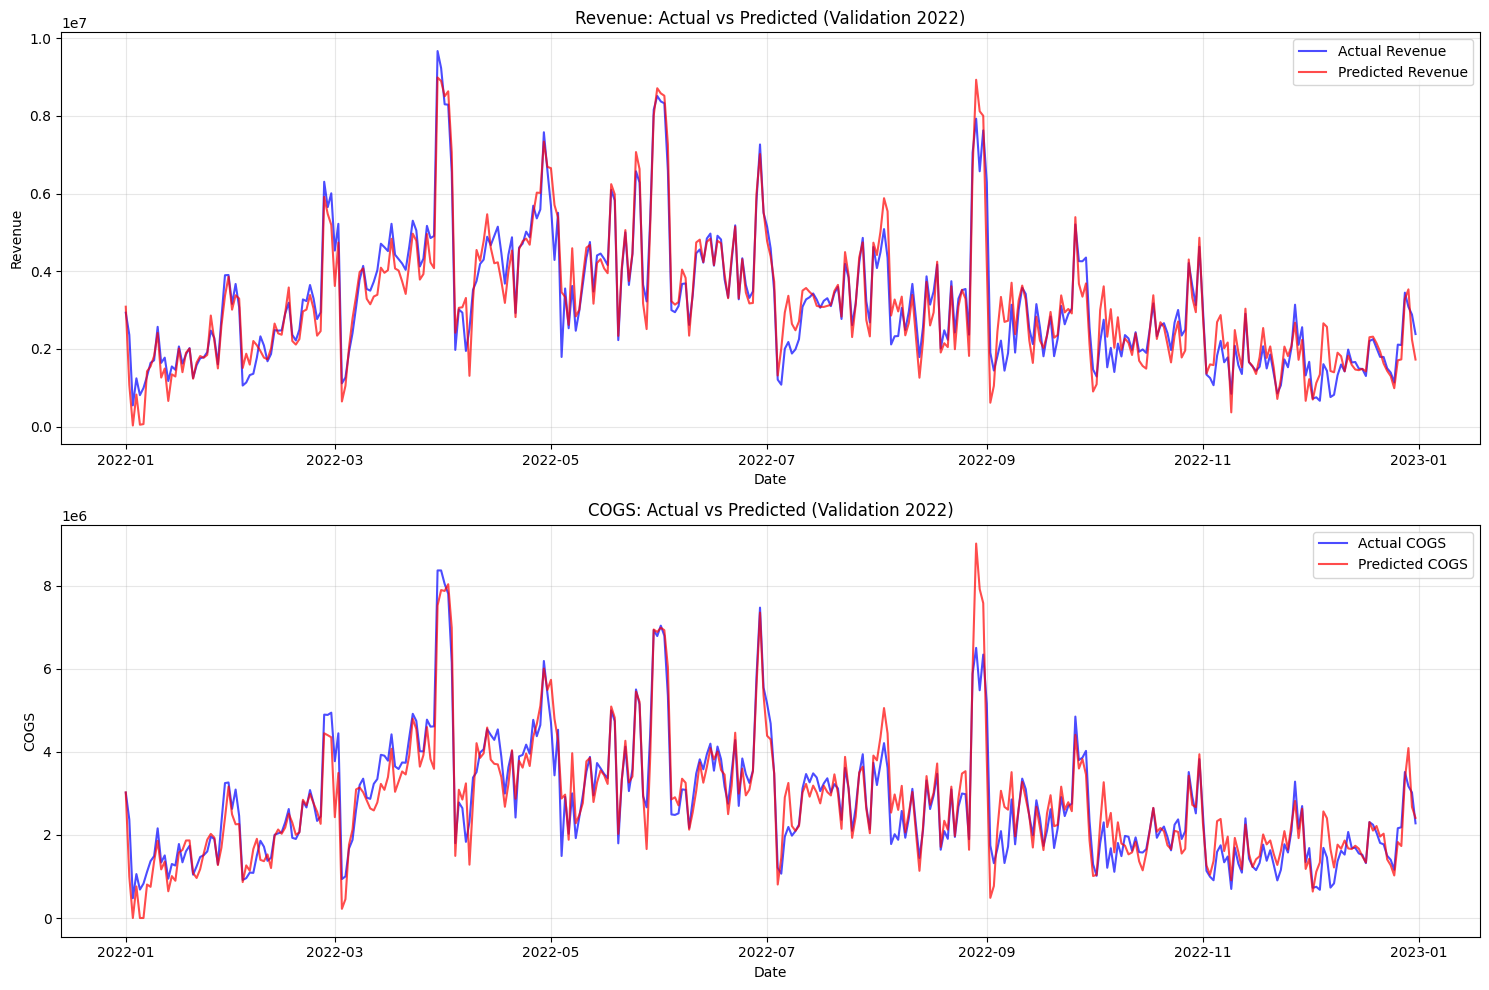

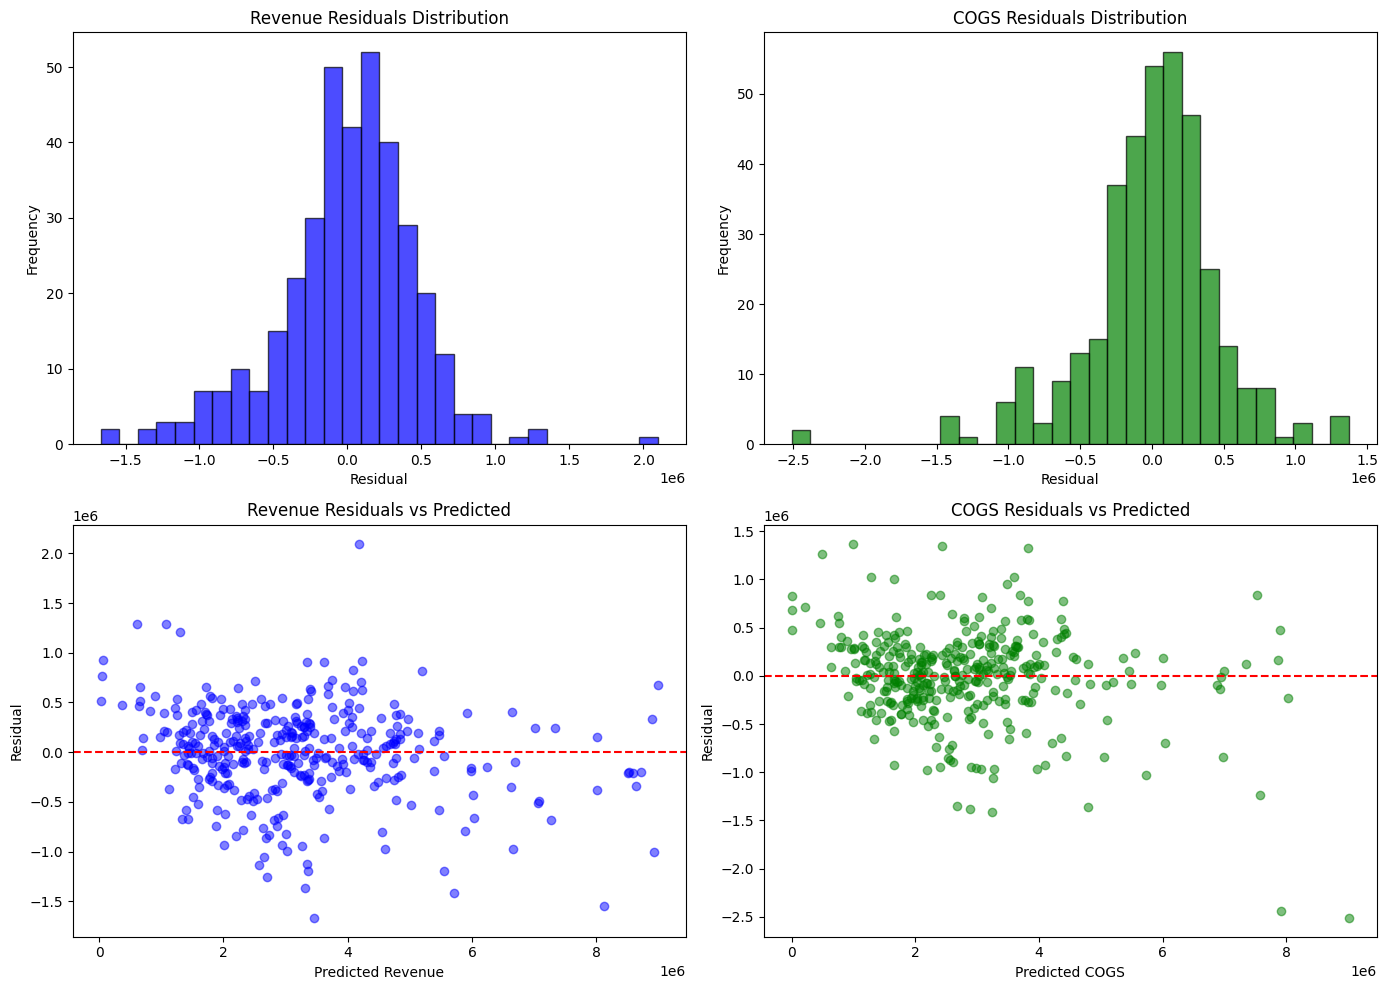


  Top 15 most important features:
                        feature  importance
        days_since_last_holiday        4381
        revenue_ratio_to_7d_avg        3762
           days_to_next_holiday        3429
       revenue_ratio_to_30d_avg        3246
       gross_margin_roll_mean_7        3221
                            day        2588
             gross_margin_lag_1        2421
             COGS_pct_change_7d        2170
            COGS_pct_change_30d        2164
                    COGS_lag_60        2095
         Revenue_pct_change_30d        2091
expanding_mean_rev_by_dayofweek        2011
         Revenue_pct_change_90d        1950
          Revenue_pct_change_7d        1923
            COGS_pct_change_90d        1897


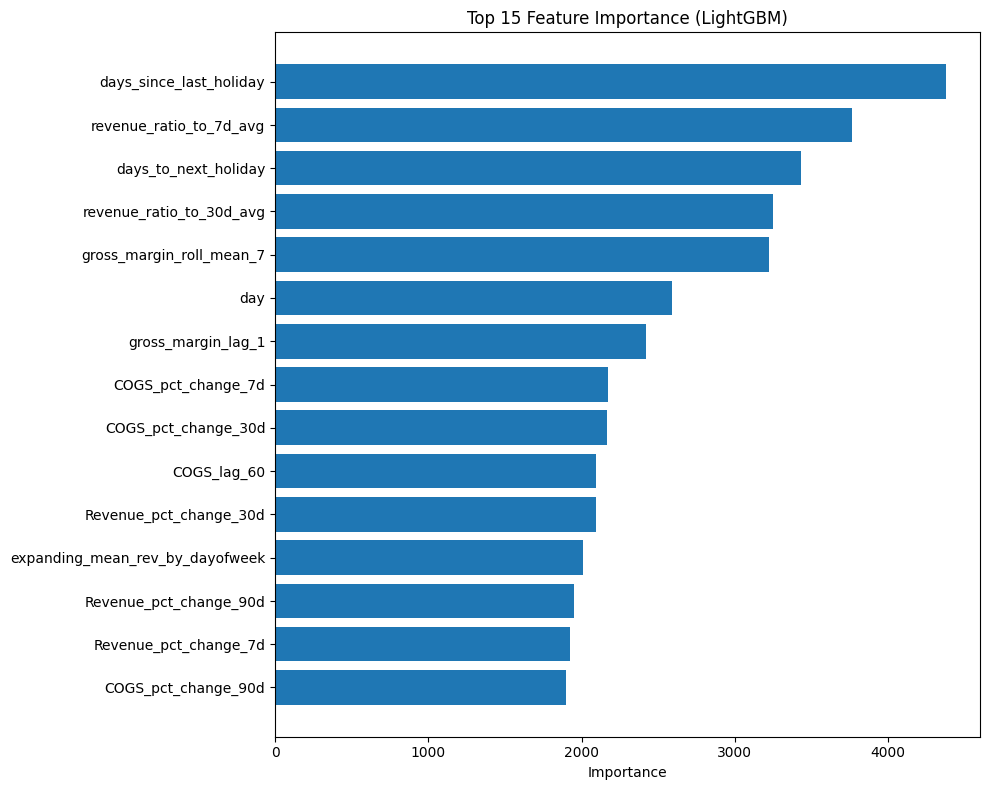

In [39]:
# ============================================
# 13. VISUALIZATION & ANALYSIS
# ============================================

print("\n[13] Generating visualizations...")

# Create comparison for validation period
comparison = pd.DataFrame({
    'Date': df.loc[val_mask, 'Date'].values,
    'Revenue_actual': y_val_rev.values,
    'Revenue_pred': final_pred_rev,
    'COGS_actual': y_val_cogs.values,
    'COGS_pred': final_pred_cogs
})

# Plot actual vs predicted
fig, axes = plt.subplots(2, 1, figsize=(15, 10))

axes[0].plot(comparison['Date'], comparison['Revenue_actual'], label='Actual Revenue', color='blue', alpha=0.7)
axes[0].plot(comparison['Date'], comparison['Revenue_pred'], label='Predicted Revenue', color='red', alpha=0.7)
axes[0].set_title('Revenue: Actual vs Predicted (Validation 2022)')
axes[0].set_xlabel('Date')
axes[0].set_ylabel('Revenue')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(comparison['Date'], comparison['COGS_actual'], label='Actual COGS', color='blue', alpha=0.7)
axes[1].plot(comparison['Date'], comparison['COGS_pred'], label='Predicted COGS', color='red', alpha=0.7)
axes[1].set_title('COGS: Actual vs Predicted (Validation 2022)')
axes[1].set_xlabel('Date')
axes[1].set_ylabel('COGS')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(DATA_DIR, 'outputs', 'validation_plot_enhanced.png'), dpi=150)
plt.show()

# Residual analysis
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

residuals_rev = comparison['Revenue_actual'] - comparison['Revenue_pred']
residuals_cogs = comparison['COGS_actual'] - comparison['COGS_pred']

axes[0, 0].hist(residuals_rev, bins=30, edgecolor='black', alpha=0.7, color='blue')
axes[0, 0].set_title('Revenue Residuals Distribution')
axes[0, 0].set_xlabel('Residual')
axes[0, 0].set_ylabel('Frequency')

axes[0, 1].hist(residuals_cogs, bins=30, edgecolor='black', alpha=0.7, color='green')
axes[0, 1].set_title('COGS Residuals Distribution')
axes[0, 1].set_xlabel('Residual')
axes[0, 1].set_ylabel('Frequency')

axes[1, 0].scatter(comparison['Revenue_pred'], residuals_rev, alpha=0.5, color='blue')
axes[1, 0].axhline(y=0, color='red', linestyle='--')
axes[1, 0].set_title('Revenue Residuals vs Predicted')
axes[1, 0].set_xlabel('Predicted Revenue')
axes[1, 0].set_ylabel('Residual')

axes[1, 1].scatter(comparison['COGS_pred'], residuals_cogs, alpha=0.5, color='green')
axes[1, 1].axhline(y=0, color='red', linestyle='--')
axes[1, 1].set_title('COGS Residuals vs Predicted')
axes[1, 1].set_xlabel('Predicted COGS')
axes[1, 1].set_ylabel('Residual')

plt.tight_layout()
plt.savefig(os.path.join(DATA_DIR, 'outputs', 'residual_analysis_enhanced.png'), dpi=150)
plt.show()

# Feature importance
feature_importance = pd.DataFrame({
    'feature': features_for_revenue,
    'importance': model_lgb_rev_final.feature_importances_
}).sort_values('importance', ascending=False)

print("\n  Top 15 most important features:")
print(feature_importance.head(15).to_string(index=False))

# Plot feature importance
plt.figure(figsize=(10, 8))
top_features = feature_importance.head(15)
plt.barh(top_features['feature'][::-1], top_features['importance'][::-1])
plt.title('Top 15 Feature Importance (LightGBM)')
plt.xlabel('Importance')
plt.tight_layout()
plt.savefig(os.path.join(DATA_DIR, 'outputs', 'feature_importance_enhanced.png'), dpi=150)
plt.show()
